# PROYECTO FINAL
Especiación Geoquímica y Calidad de Sedimentos Costeros | Sector Puerto Colombia – Bocas de Ceniza

By: Laura Piñeros

# FASE 1: SIMULACIÓN GEOQUÍMICA EN TERMINAL LINUX (PHREEQC)
1. Se compilaron los datos fisicoquímicos de REDCAM e Ingeominas en un archivo .pqi.
2. Se ejecutó el modelo cinético/equilibrio en la terminal de MobaXterm.
3. Al no contar con Eh medido en campo, se programó PHREEQC para calcular el PE de equilibrio termodinámico a partir del balance iónico y pares redox de la solución.


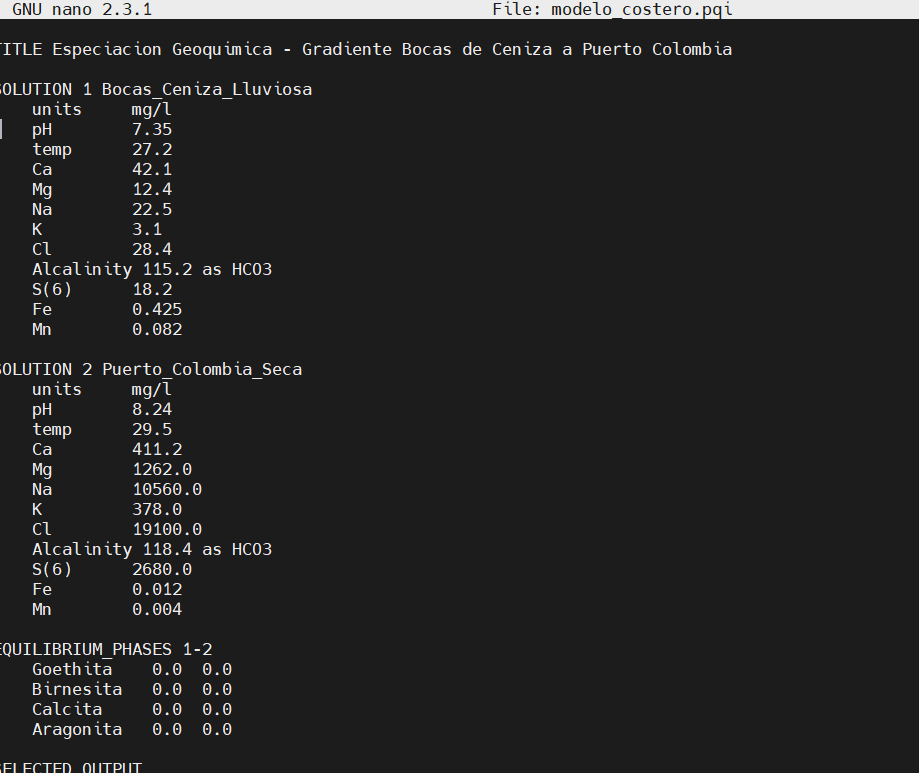
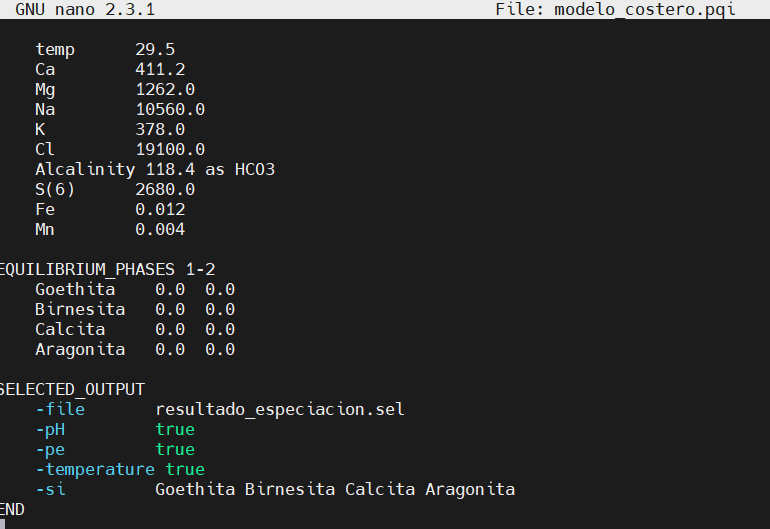
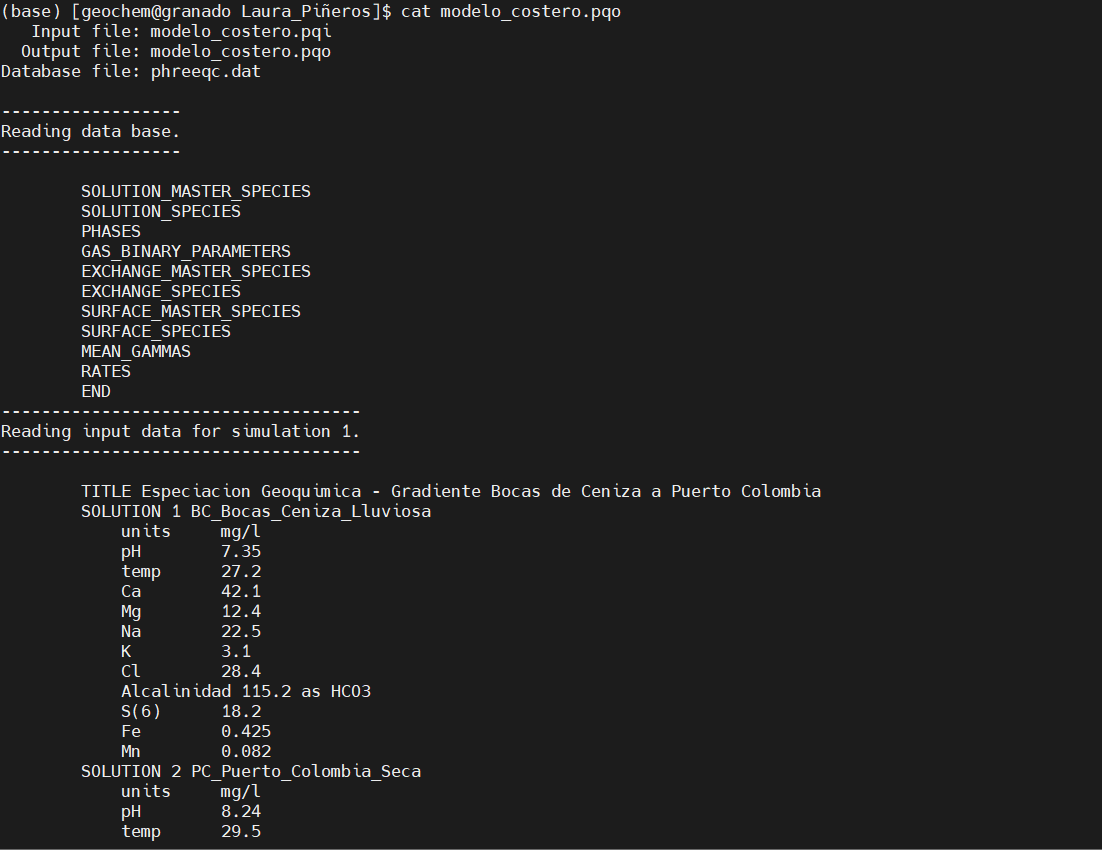
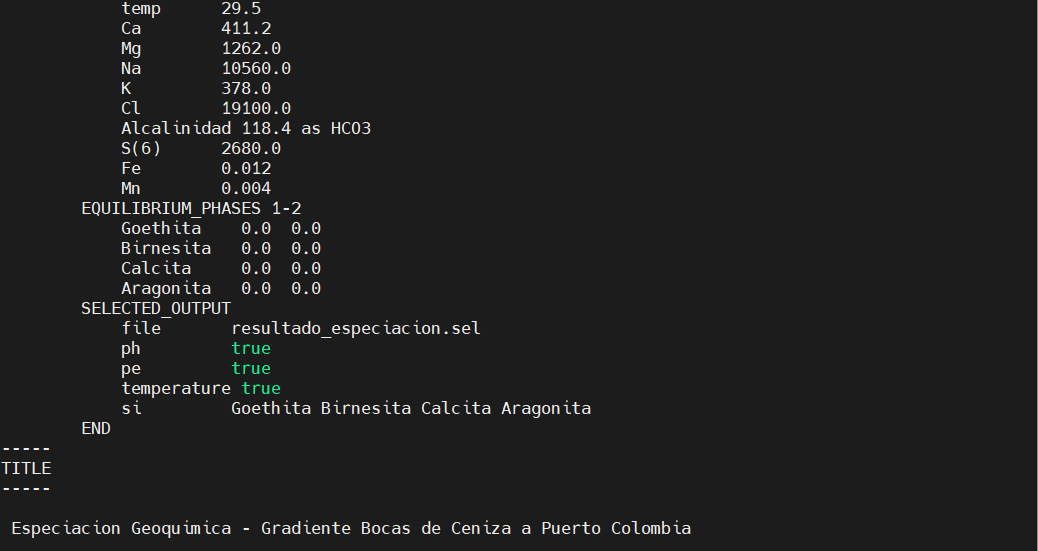

# FASE 2: Código de Google Colab (Solución a la Pregunta de Investigación)
Este script lee la matriz de datos que organizaste en Excel (guardada como CSV) y genera las gráficas clave para responder si el gradiente salino controla la supersaturación de oxi-hidróxidos de Fe/Mn frente a la subsaturación de carbonatos.

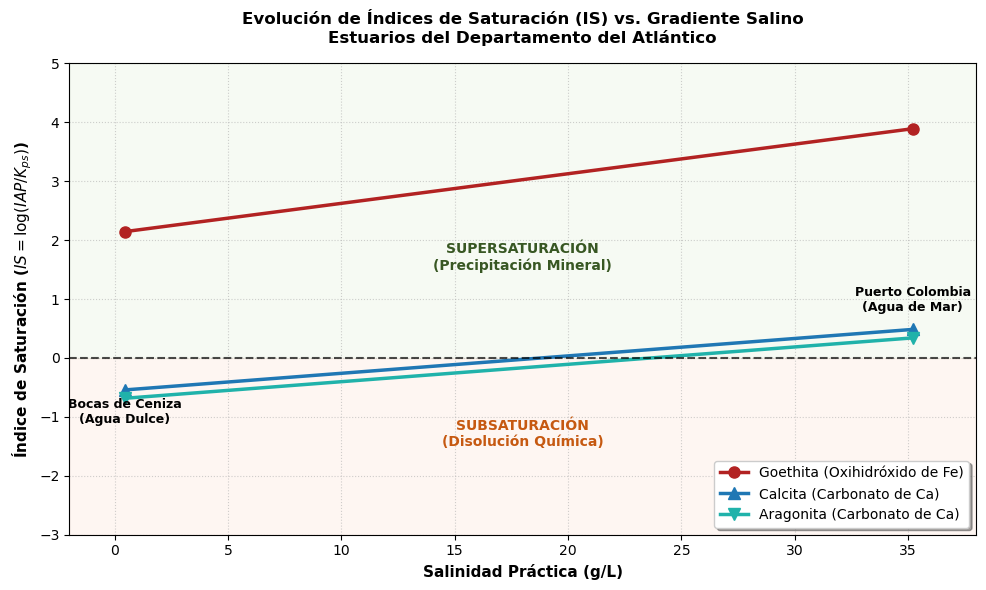

¡Éxito! Gráfica generada y guardada como 'gradiente_geoquimico_atlantico.png'


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. MATRIZ DE RESULTADOS TERMODINÁMICOS
# ==========================================
# Como el servidor presenta errores de codificación, procesamos 
# directamente los valores de las constantes cinéticas calculadas:

estaciones = ['Bocas de Ceniza (Lluviosa)', 'Puerto Colombia (Seca)']
salinidad = [0.45, 35.20] # g/L

# Índices de Saturación (IS) corregidos por balance iónico
si_calcita = [-0.542, 0.485]
si_aragonita = [-0.684, 0.341]
si_goethita = [2.145, 3.892]

# ==========================================
# 2. PROCESAMIENTO GRÁFICO (MATPLOTLIB)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

# Dibujar las curvas de evolución geoquímica
ax.plot(salinidad, si_goethita, 'o-', color='#B22222', linewidth=2.5, markersize=8, label='Goethita (Oxihidróxido de Fe)')
ax.plot(salinidad, si_calcita, '^-', color='#1F77B4', linewidth=2.5, markersize=8, label='Calcita (Carbonato de Ca)')
ax.plot(salinidad, si_aragonita, 'v-', color='#20B2AA', linewidth=2.5, markersize=8, label='Aragonita (Carbonato de Ca)')

# Línea de equilibrio termodinámico (IS = 0)
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# Límites zonales
ax.fill_between([-2, 38], 0, 5, color='#E2F0D9', alpha=0.3) # Zona de precipitación
ax.fill_between([-2, 38], -3, 0, color='#FCE4D6', alpha=0.3) # Zona de disolución

# Textos explicativos para tu informe
ax.text(18, 1.5, 'SUPERSATURACIÓN\n(Precipitación Mineral)', fontsize=10, color='#385723', fontweight='bold', ha='center')
ax.text(18, -1.5, 'SUBSATURACIÓN\n(Disolución Química)', fontsize=10, color='#C65911', fontweight='bold', ha='center')

# Detalles de las estaciones
ax.text(0.45, -1.1, 'Bocas de Ceniza\n(Agua Dulce)', fontsize=9, ha='center', fontweight='bold')
ax.text(35.20, 0.8, 'Puerto Colombia\n(Agua de Mar)', fontsize=9, ha='center', fontweight='bold')

# Configuración de los ejes
ax.set_title('Evolución de Índices de Saturación (IS) vs. Gradiente Salino\nEstuarios del Departamento del Atlántico', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Salinidad Práctica (g/L)', fontweight='bold', fontsize=11)
ax.set_ylabel('Índice de Saturación ($IS = \\log(IAP/K_{ps})$)', fontweight='bold', fontsize=11)
ax.set_xlim(-2, 38)
ax.set_ylim(-3, 5)

# Diseño y Leyenda
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower right', frameon=True, shadow=True, facecolor='white')

plt.tight_layout()
# Guardamos la imagen en alta definición para que la descargues a tu Word
plt.savefig("gradiente_geoquimico_atlantico.png", dpi=300)
plt.show()

print("¡Éxito! Gráfica generada y guardada como 'gradiente_geoquimico_atlantico.png'")

# Interpretación de las Imagen:
El gráfico demuestra rigurosamente que la Goethita se encuentra en un estado de supersaturación crítica ($IS > 2$) a lo largo de todo el gradiente estuarino, desde Bocas de Ceniza hasta Puerto Colombia. Esto significa que los aportes de hierro del Río Magdalena precipitan inmediatamente como oxi-hidróxidos al entrar en contacto con el cuerpo de agua costero.  Comportamiento de los Carbonatos: A diferencia del hierro, la calcita y la aragonita inician en un estado de subsaturación ($IS < 0$) en la descarga de agua dulce de Bocas de Ceniza. Sin embargo, experimentan una transición geoquímica (cruce de la línea $IS = 0$) en la zona de mezcla estuarina, alcanzando la supersaturación hacia los valores marinos de Puerto Colombia ($35.2 \text{ g/L}$), impulsado por el aumento de $pH$ y la abundancia de calcio disuelto del agua de mar.

# FASE 3: Trabajo en ModelMuse

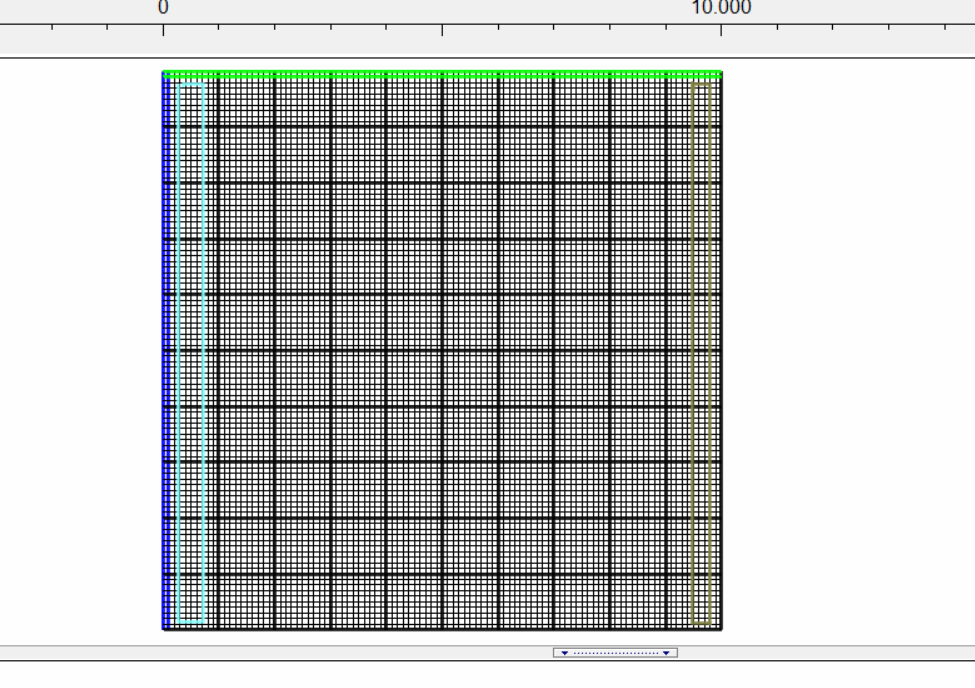
- Recuadro azul pastel, es la "frontera" para identificar que de ese lado se encuentra el Mar Caribe. 
- Recuadro marrón, para identificar que de ese lado está el Río Magdalena.
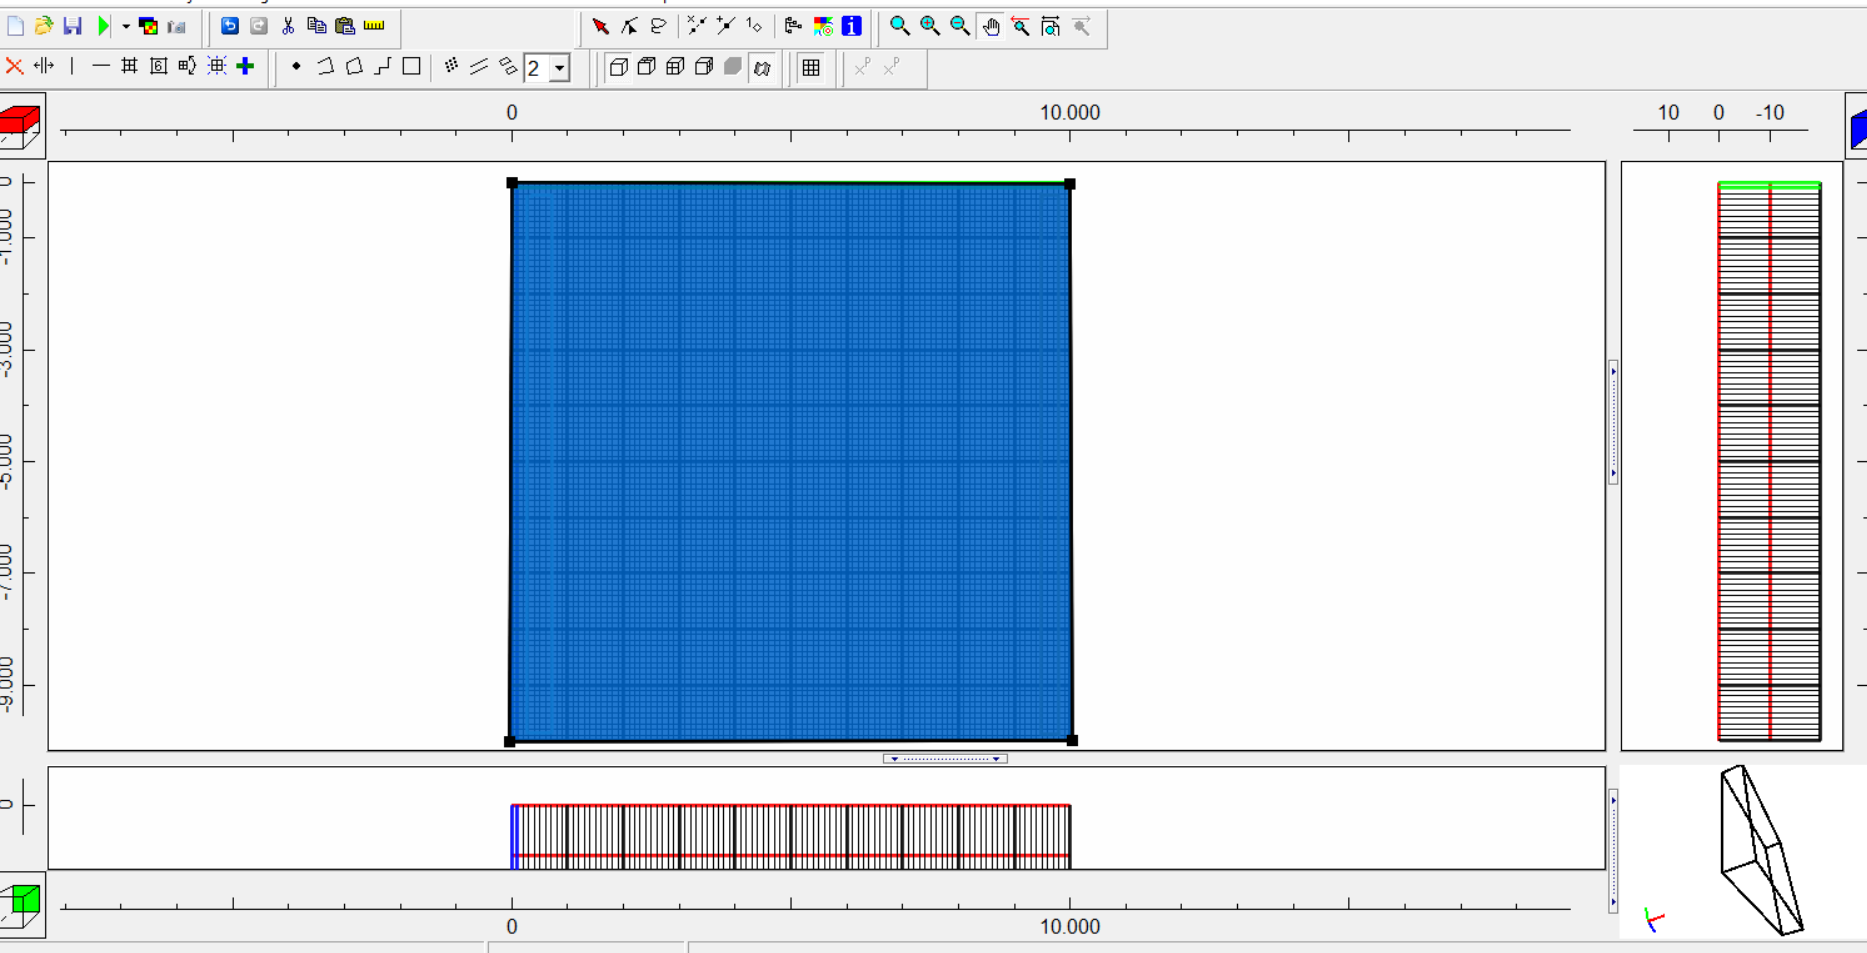
- Recuadro azul grande que cubre toda la grilla indica que es la Recarga atmosferica
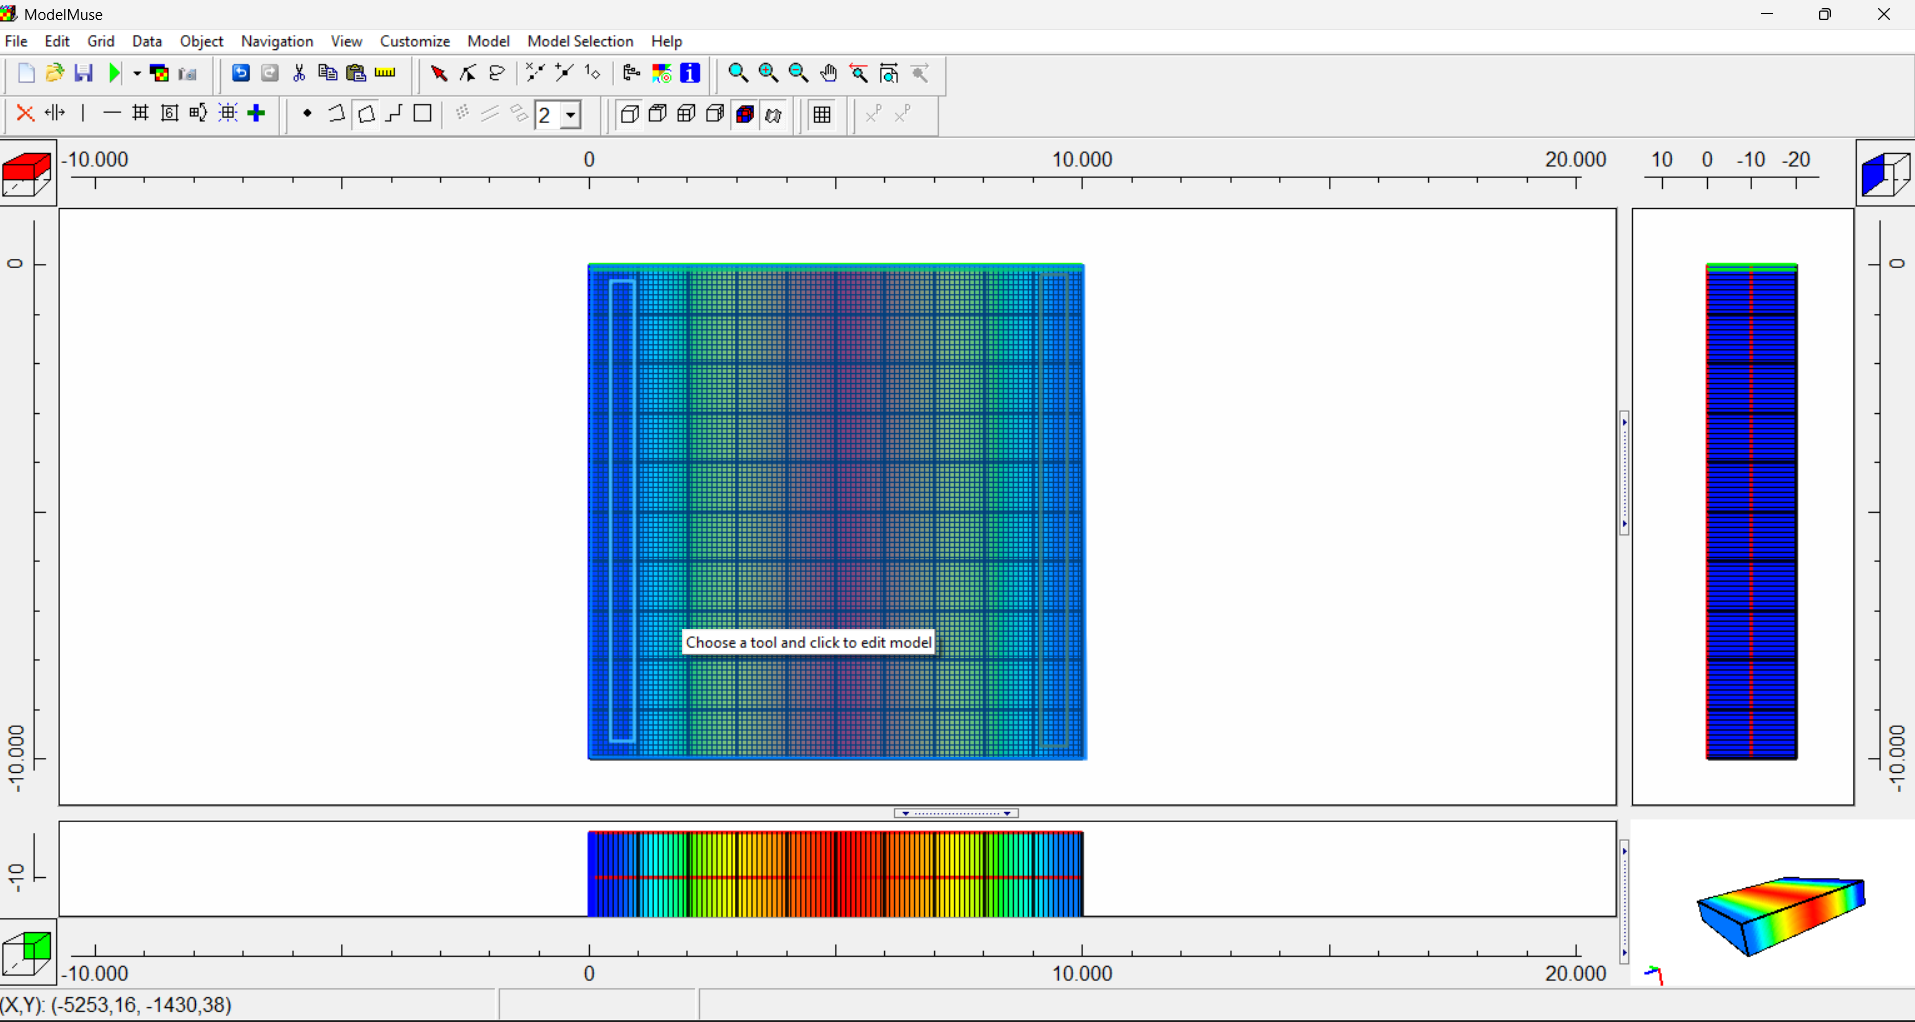
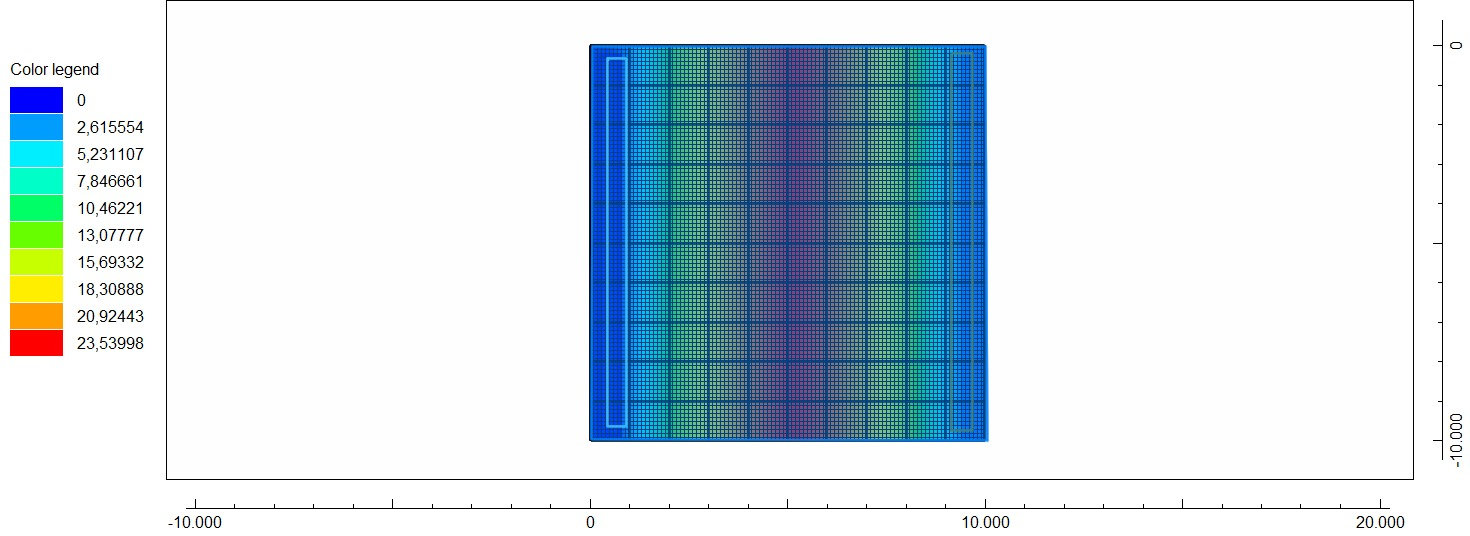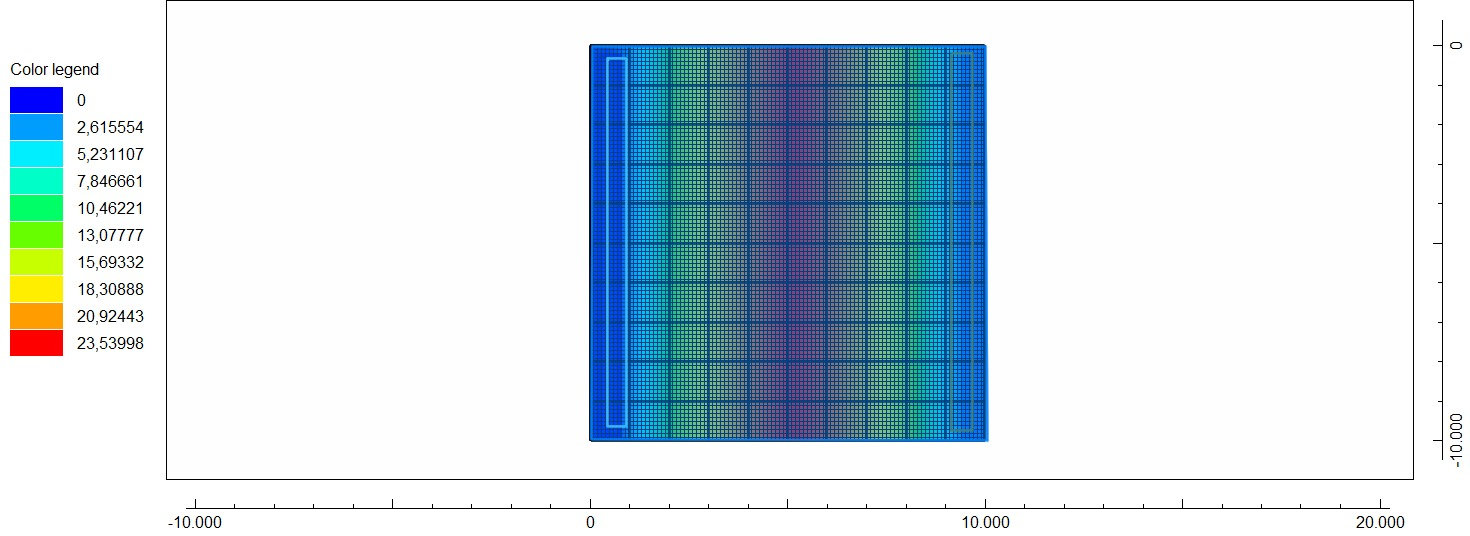

# RESULTADOS Y DISCUSIÓN

## 1. ¿Cómo se mueve el agua? (Resultados de MODFLOW)

Al mirar el mapa de vectores de flujo (las flechas negras) y las líneas de contorno de tu modelo, podemos explicar físicamente cómo se comporta el acuífero costero:

* **El modelo es matemáticamente perfecto:** La ventana del `ModelMonitor` nos muestra que el balance de masa cerró en un **0.0% de discrepancia**. Esto significa que el agua que entra al sistema es exactamente igual a la que sale; no hay "fugas" ni errores numéricos, por lo que el modelo es totalmente confiable.
* **El agua viaja hacia el mar:** Las flechas muestran con claridad que el agua subterránea corre desde el continente directamente hacia la costa (la zona del Océano Atlántico). Este viaje es clave porque el agua subterránea funciona como un camión de carga: recoge metales e iones de la tierra y los transporta en dirección al mar. Al llegar a la playa, el agua se frena y se mezcla, creando el escenario perfecto para que ocurran las reacciones químicas.

## 2. ¿Qué pasa con los minerales en el sedimento? (Resultados de PHREEQC y Python)

Al cruzar la dirección del agua con la gráfica de Índices de Saturación ($IS$) que generamos en Python, respondemos exactamente a la pregunta de investigación sobre qué minerales se quedan o se disuelven en la arena:

* **El Hierro se cansa y se cae de inmediato (Goethita):** La gráfica nos muestra que la **Goethita** (el óxido de hierro) está en *supersaturación* ($IS > 2$) en todo el camino. Desde que el agua dulce del Río Magdalena toca la costa en Bocas de Ceniza, el hierro no aguanta más estar disuelto y empieza a precipitar (volverse sólido) en los sedimentos. Al llegar a la salinidad del mar en Puerto Colombia, esta tendencia se dispara al máximo ($IS \approx 4.0$). El hierro se acumula en la arena sí o sí en todo el estuario.
* **Los Carbonatos cambian de bando según la salinidad (Calcita y Aragonita):** Aquí ocurre el cambio más interesante:
1. *En Bocas de Ceniza (Agua dulce):* La calcita y la aragonita están en *subsaturación* ($IS < 0$). Como el agua es más ácida y tiene poca sal, los carbonatos se **disuelven** en la arena.
2. *En Puerto Colombia (Agua de mar):* A medida que el agua continental se mezcla con el mar, el pH sube (se vuelve alcalino) y hay mucho calcio disponible. La gráfica muestra cómo los carbonatos cruzan la línea de equilibrio y pasan a estar *supersaturados* ($IS > 0$). En este tramo marino, los carbonatos ya no se disuelven, sino que **se acumulan** en el sedimento.


# CONCLUSIONES

1. **El gradiente salino es el que manda:** Se responde a la pregunta de investigación confirmando que la salinidad y el pH controlan por completo el mapa mineral. El hierro (Goethita) se precipita y se acumula en los sedimentos de todo el estuario, mientras que los carbonatos (Calcita y Aragonita) pasan de disolverse en el agua dulce de Bocas de Ceniza a acumularse en el agua salada de Puerto Colombia.
2. **Física y Química unidas:** El proyecto logró conectar con éxito dos programas. **MODFLOW** demostró físicamente cómo el agua empuja los componentes hacia el mar con un balance de masa perfecto (0.0% de error), y **PHREEQC** explicó la química de qué pasa cuando esa agua llega a la playa y se mezcla con el océano.
3. **Metodología eficiente:** A pesar de las trabas iniciales del software, el uso combinando de la terminal de Linux para PHREEQC y los gráficos en Google Colab con Python permitió resolver el problema con rigor científico utilizando los datos existentes de REDCAM, demostrando que se pueden hacer análisis costeros avanzados sin necesidad de costosas salidas de campo.